In [18]:
from paddleocr import PaddleOCR
import cv2
import matplotlib.pyplot as plt
import numpy as np

/tmp/ipykernel_27355/4291049219.py:1: DeprecationWarning: The parameter `use_angle_cls` has been deprecated and will be removed in the future. Please use `use_textline_orientation` instead.
  ocr= PaddleOCR(use_angle_cls=True, lang= 'en')
Creating model: ('PP-LCNet_x1_0_doc_ori', None)
Using official model (PP-LCNet_x1_0_doc_ori), the model files will be automatically downloaded and saved in /home/sandeep/.paddlex/official_models.


Fetching 6 files: 100%|██████████| 6/6 [00:00<00:00, 8955.81it/s]
Creating model: ('UVDoc', None)
The model(UVDoc) is not supported to run in MKLDNN mode! Using `paddle` instead!
Using official model (UVDoc), the model files will be automatically downloaded and saved in /home/sandeep/.paddlex/official_models.
Fetching 6 files: 100%|██████████| 6/6 [00:00<00:00, 5441.26it/s]
Creating model: ('PP-LCNet_x1_0_textline_ori', None)
Using official model (PP-LCNet_x1_0_textline_ori), the model files will be automatically downloaded and saved in /home/sandeep/.paddlex/official_models.
Fetching 6 files: 100%|██████████| 6/6 [00:00<00:00, 5012.11it/s]
Creating model: ('PP-OCRv5_server_det', None)
Using official model (PP-OCRv5_server_det), the model files will be automatically downloaded and saved in /home/sandeep/.paddlex/official_models.
Fetching 6 files: 100%|██████████| 6/6 [00:00<00:00, 9151.21it/s]
Creating model: ('PP-OCRv5_server_rec', None)
Using official model (PP-OCRv5_server_rec), the

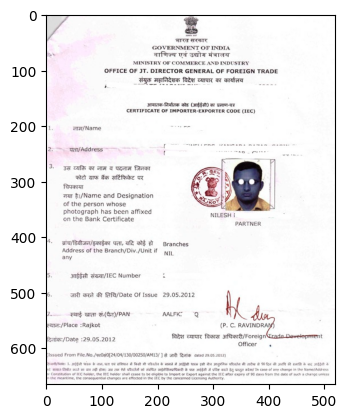

In [10]:
ocr= PaddleOCR(use_angle_cls=True, lang= 'en')
img_path= r'/home/sandeep/Desktop/Himanshu/personal/practice/data/bank_kyc_sample.jpg'
img= cv2.imread(img_path)


plt.figure()
plt.imshow(img)
plt.show()

In [6]:
result= ocr.predict(img)
result

[{'input_path': None,
  'page_index': None,
  'doc_preprocessor_res': {'input_path': None,
   'page_index': None,
   'input_img': array([[[225, ..., 225],
           ...,
           [254, ..., 254]],
   
          ...,
   
          [[249, ..., 251],
           ...,
           [254, ..., 254]]], shape=(665, 519, 3), dtype=uint8),
   'model_settings': {'use_doc_orientation_classify': True,
    'use_doc_unwarping': True},
   'angle': 0,
   'rot_img': array([[[225, ..., 225],
           ...,
           [254, ..., 254]],
   
          ...,
   
          [[249, ..., 251],
           ...,
           [254, ..., 254]]], shape=(665, 519, 3), dtype=uint8),
   'output_img': array([[[250, ..., 250],
           ...,
           [255, ..., 255]],
   
          ...,
   
          [[250, ..., 249],
           ...,
           [254, ..., 254]]], shape=(665, 519, 3), dtype=uint8)},
  'dt_polys': [array([[221,   8],
          ...,
          [221,  22]], shape=(4, 2), dtype=int16),
   array([[175,  23],
   

In [14]:
result[0].keys()

dict_keys(['input_path', 'page_index', 'doc_preprocessor_res', 'dt_polys', 'model_settings', 'text_det_params', 'text_type', 'text_rec_score_thresh', 'rec_texts', 'rec_scores', 'rec_polys', 'vis_fonts', 'textline_orientation_angles', 'rec_boxes'])

In [19]:
data = result[0]  # the first result dict
output_img = data['doc_preprocessor_res']['output_img']  # processed image (may be rotated/unwarped)
output_img = output_img.copy()  # Make it writable and contiguous
output_img = output_img.astype('uint8')
boxes = data['dt_polys']  # list of 4-point arrays

# Step 5: Draw boxes
for box in boxes:
    pts = np.array(box, dtype=np.int32).reshape((-1, 1, 2))
    cv2.polylines(output_img, [pts], isClosed=True, color=(0, 255, 0), thickness=2)

# Step 6: Show or save result
cv2.imshow("OCR with Boxes", output_img)
cv2.waitKey(0)
cv2.destroyAllWindows()

: 

In [1]:
from paddleocr import PaddleOCR
import cv2
import matplotlib.pyplot as plt
import numpy as np

/home/sandeep/Desktop/Himanshu/personal/practice/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
from paddleocr import PaddleOCR
import os
import cv2
import matplotlib.pyplot as plt


ocr = PaddleOCR(
    use_doc_orientation_classify=False,
    use_doc_unwarping=False,
    use_textline_orientation=False)

/home/sandeep/Desktop/Himanshu/personal/practice/venv/lib/python3.10/site-packages/paddle/utils/cpp_extension/extension_utils.py:715: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)
Creating model: ('PP-OCRv5_server_det', None)
Using official model (PP-OCRv5_server_det), the model files will be automatically downloaded and saved in /home/sandeep/.paddlex/official_models.
Fetching 6 files: 100%|██████████| 6/6 [00:00<00:00, 8242.98it/s]
Creating model: ('PP-OCRv5_server_rec', None)
Using official model (PP-OCRv5_server_rec), the model files will be automatically downloaded and saved in /home/sandeep/.paddlex/official_models.
Fetching 6 files: 100%|██████████| 6/6 [00:00<00:00, 4751.85it/s]


In [4]:
result = ocr.predict(
    input="/home/sandeep/Desktop/Himanshu/personal/practice/data/bank_kyc_sample.jpg")

In [5]:
for res in result:
    res.print()
    res.save_to_img("output")
    res.save_to_json("output")

{'res': {'input_path': '/home/sandeep/Desktop/Himanshu/personal/practice/data/bank_kyc_sample.jpg', 'page_index': None, 'model_settings': {'use_doc_preprocessor': True, 'use_textline_orientation': False}, 'doc_preprocessor_res': {'input_path': None, 'page_index': None, 'model_settings': {'use_doc_orientation_classify': False, 'use_doc_unwarping': False}, 'angle': -1}, 'dt_polys': array([[[231,  42],
        ...,
        [231,  51]],

       ...,

       [[  0, 646],
        ...,
        [  0, 659]]], shape=(48, 4, 2), dtype=int16), 'text_det_params': {'limit_side_len': 64, 'limit_type': 'min', 'thresh': 0.3, 'max_side_limit': 4000, 'box_thresh': 0.6, 'unclip_ratio': 1.5}, 'text_type': 'general', 'textline_orientation_angles': array([-1, ..., -1], shape=(48,)), 'text_rec_score_thresh': 0.0, 'rec_texts': ['', 'GOVERNMENT OFINDIA', 'a ', 'MINISTRYOFCOMMERCEANDINDUSTRY', 'OFFICEOFJT.DIRECTOR GENERAL OFFOREIGN TRADE', 'H fae c 可 a', '34（)', 'CERTIFICATE OF IMPORTER-EXPORTER CODE (IEC)', '1.